# GLM-Based Insurance Pricing Model

**Business Travel Insurance — Claim Frequency & Severity Modelling**

This notebook develops a multiplicative Generalised Linear Model (GLM) to price business travel insurance policies.  
The model is structured as:

1610\text{price} = \gamma_0 \prod_{k=1}^{M} \gamma_{k,i}1610

where $\gamma_0$ is the base premium and $\gamma_{k,i}$ are risk factors for variable $, group $.

---

**Key tasks:**
- Exploratory data analysis and variable grouping
- Separate GLM modelling of claim frequency (Poisson) and severity (Gamma)
- Model selection via Likelihood-Ratio Test, AIC/BIC, and Wald tests
- Business validation: Gini score and Risk Ratio analysis
- Base-level determination at a target 90% risk ratio


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import glm
import scipy.stats as stats
import re
import warnings

warnings.filterwarnings("ignore")

## Read Data

In [2]:
df = pd.read_csv(r"data/train.csv", sep=",", decimal=".")
df_valid = pd.read_csv(r"data/validation.csv", sep=";", decimal=".")
df_eval = pd.read_csv(r"data/eval.csv", sep=",", decimal=".")

In [3]:
print(f"Training - rows: {df.shape[0]} columns: {df.shape[1]}")
print(f"Validation - rows: {df_valid.shape[0]} columns: {df_valid.shape[1]}")
print(f"Eval - rows: {df_eval.shape[0]} columns: {df_eval.shape[1]}")

Training - rows: 149486 columns: 10
Validation - rows: 79631 columns: 10
Eval - rows: 79631 columns: 7


In [4]:
df.head()

,RiskYear,NumberOfPersons,ActivityCode,TravellingArea,DangerousAreas,CompanyAge,FinancialRating,Duration,ClaimCost,NumberOfClaims
0,2018,58.0,L,Whole world,Excluded,70.075294,AA,0.9994,0.0,0
1,2018,30.0,G,Whole world,Excluded,66.841890,AAA,0.2519,0.0,0
2,2018,150.0,C,Whole world,Excluded,60.876114,AA,0.3340,0.0,0
3,2021,54.0,Q,Whole world,Excluded,63.608486,AAA,0.4956,0.0,0
4,2019,19.0,R,Whole world,Excluded,31.096510,A,0.8625,0.0,0


In [5]:
df_valid.head()

,RiskYear,NumberOfPersons,ActivityCode,TravellingArea,DangerousAreas,CompanyAge,FinancialRating,Duration,ClaimCost,NumberOfClaims
0,2023,2.0,L,Whole world,Excluded,26.165640,missing,0.4135,0.0,0
1,2023,4.0,C,Whole world,Excluded,125.316910,AAA,0.8652,0.0,0
2,2024,3.0,Q,Whole world,Excluded,66.606440,AAA,0.4983,0.0,0
3,2023,1.0,G,Whole world,Excluded,43.460644,AA,0.4956,0.0,0
4,2024,50.0,L,Whole world,Excluded,42.447640,AA,0.0849,0.0,0


In [6]:
df_eval.head()

,RiskYear,NumberOfPersons,ActivityCode,TravellingArea,DangerousAreas,CompanyAge,FinancialRating
0,2023,2.0,L,Whole world,Excluded,26.165640,missing
1,2023,4.0,C,Whole world,Excluded,125.316910,AAA
2,2024,3.0,Q,Whole world,Excluded,66.606440,AAA
3,2023,1.0,G,Whole world,Excluded,43.460644,AA
4,2024,50.0,L,Whole world,Excluded,42.447640,AA


## Exploratory Data Analysis

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149486 entries, 0 to 149485
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   RiskYear         149486 non-null  int64  
 1   NumberOfPersons  149486 non-null  float64
 2   ActivityCode     149486 non-null  str    
 3   TravellingArea   149486 non-null  str    
 4   DangerousAreas   149486 non-null  str    
 5   CompanyAge       149486 non-null  float64
 6   FinancialRating  149486 non-null  str    
 7   Duration         149486 non-null  float64
 8   ClaimCost        149486 non-null  float64
 9   NumberOfClaims   149486 non-null  int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 11.4 MB


In [8]:
df.isna().sum()

RiskYear           0
NumberOfPersons    0
ActivityCode       0
TravellingArea     0
DangerousAreas     0
CompanyAge         0
FinancialRating    0
Duration           0
ClaimCost          0
NumberOfClaims     0
dtype: int64

In [9]:
df["AvgClaimCost"] = (df["ClaimCost"] / df["NumberOfClaims"]).fillna(0)

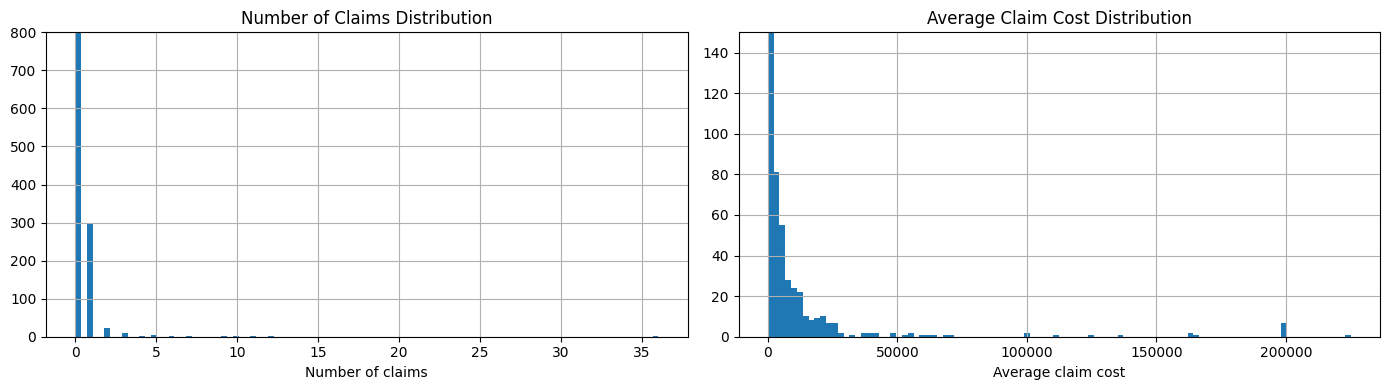

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df["NumberOfClaims"].hist(bins=100, ax=axes[0])
axes[0].set_ylim((0, 800)) 
axes[0].set_xlabel("Number of claims")
axes[0].set_title("Number of Claims Distribution")

df["AvgClaimCost"].hist(bins=100, ax=axes[1])
axes[1].set_ylim((0, 150)) 
axes[1].set_xlabel("Average claim cost")
axes[1].set_title("Average Claim Cost Distribution")
plt.tight_layout()
plt.show()

In [11]:
risk_year_agg = df.groupby("RiskYear").agg(
    Total_Duration=("Duration", "sum"),
    Total_Claims=("NumberOfClaims", "sum"),
    Total_ClaimCost=("ClaimCost", "sum")
)
risk_year_agg["Observed_Frequency"] = risk_year_agg["Total_Claims"] / risk_year_agg["Total_Duration"]
risk_year_agg["Observed_Severity"] = risk_year_agg["Total_ClaimCost"] / risk_year_agg["Total_Claims"]
print(risk_year_agg)

          Total_Duration  Total_Claims  Total_ClaimCost  Observed_Frequency  \
RiskYear                                                                      
2018           9700.9880            78        678565.31            0.008040   
2019          14988.0128           138       1052952.83            0.009207   
2020          15562.5173           187       4049296.15            0.012016   
2021          15440.2236            28        194618.09            0.001813   
2022          17816.1361            78       1139060.94            0.004378   

          Observed_Severity  
RiskYear                     
2018            8699.555256  
2019            7630.092971  
2020           21653.990107  
2021            6950.646071  
2022           14603.345385  


In [12]:
df[["NumberOfPersons", "CompanyAge"]].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99])

,NumberOfPersons,CompanyAge
count,149486.000000,149486.000000
mean,55.529528,15.047460
std,713.604689,15.162737
min,1.000000,0.005476
25%,1.000000,4.043806
50%,3.000000,10.053388
75%,8.000000,21.924710
90%,25.000000,33.204655
95%,55.000000,45.505817
99%,1000.000000,70.116356


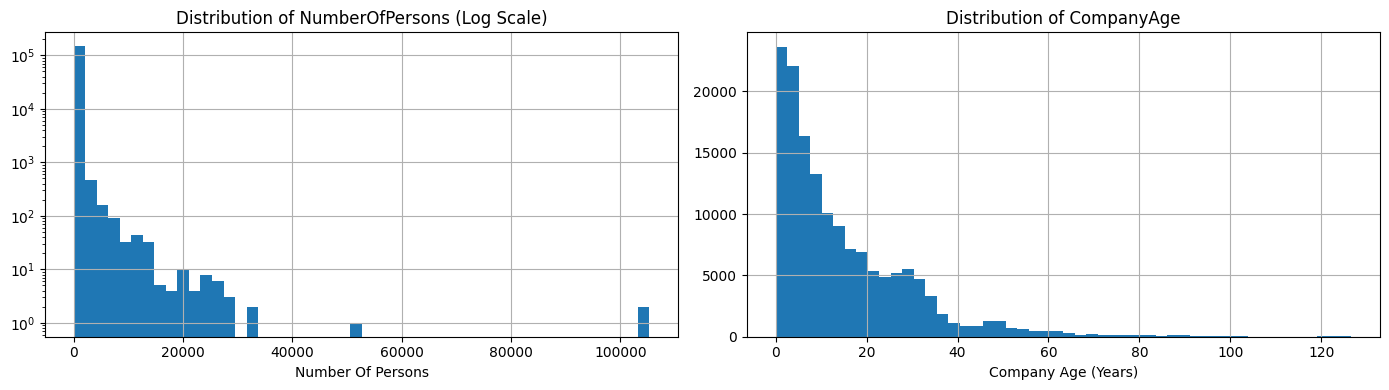

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df["NumberOfPersons"].hist(bins=50, ax=axes[0], log=True)
axes[0].set_title("Distribution of NumberOfPersons (Log Scale)")
axes[0].set_xlabel("Number Of Persons")

df["CompanyAge"].hist(bins=50, ax=axes[1])
axes[1].set_title("Distribution of CompanyAge")
axes[1].set_xlabel("Company Age (Years)")
plt.tight_layout()
plt.show()

## Grouping

In [14]:
def apply_all_groupings(df_in):
    """Applies numerical and categorical binning rules."""
    d = df_in.copy()
    
    # NumberOfPersons
    d['NumberOfPersons_Group'] = pd.cut(
        d['NumberOfPersons'], 
        bins=[-np.inf, 8, 25, 55, 1000, np.inf], 
        labels=['1-8', '9-25', '26-55', '56-1000', '1000+']
    ).astype(str).replace('nan', 'Missing').astype('category')
    
    # CompanyAge
    d['CompanyAge_Group'] = pd.cut(
        d['CompanyAge'], 
        bins=[-np.inf, 2, 7, 18, 35, 50, np.inf], 
        labels=['0-2', '3-7', '8-18', '19-35', '36-50', '51+']
    ).astype(str).replace('nan', 'Missing').astype('category')
    
    # FinancialRating
    d['FinancialRating_Group'] = d['FinancialRating'].map({
        'AAA': 'AAA', 'AA': 'AA', 'A': 'A/Standard', 
        'B': 'B/C', 'C': 'B/C', 'AN': 'New', 
        'IR': 'A/Standard', 'missing': 'A/Standard'
    })
    
    # TravellingArea & DangerousAreas
    d['TravellingArea_Group'] = d['TravellingArea'].map({
        'Whole world': 'World', 'Europe': 'World', 
        'Sweden': 'Nordics', 'Nordic countries': 'Nordics'
    })
    d['DangerousAreas'] = d.get('DangerousAreas', d.get('DangerousAreas_Group'))
    
    # ActivityCode
    d['Activity_Group'] = d['ActivityCode'].map({
        "B": "Industry", "D": "Industry", "E": "Industry", "U": "Industry",
        "G": "Service", "I": "Service", "S": "Service", "T": "Service"
    }).fillna('Other')
    
    return d

In [15]:
df = apply_all_groupings(df)
df_valid = apply_all_groupings(df_valid)
df_eval = apply_all_groupings(df_eval)

In [16]:
def validate_and_plot_grouping(df, col):
    """Perform validity checks and a visual check of risk homogeneity."""
    
    df_agg = df.groupby(col, observed=False).agg(
        Duration=('Duration', 'sum'),
        NumberOfClaims=('NumberOfClaims', 'sum'),
        ClaimCost=('ClaimCost', 'sum')
    )
    
    df_agg['Frequency'] = df_agg['NumberOfClaims'] / df_agg['Duration']
    df_agg['AvgClaimCost'] = (df_agg['ClaimCost'] / df_agg['NumberOfClaims']).fillna(0)
    df_agg['YearlyClaimCost'] = df_agg['ClaimCost'] / df_agg['Duration']
    
    
    print(df_agg.to_string())
    
    zero_claims = df_agg[df_agg['NumberOfClaims'] == 0].index.tolist()
    low_dur = df_agg[df_agg['Duration'] < 10].index.tolist()
    
    print(f"Claims Check: {'OK' if not zero_claims else f'Groups with 0 claims: {zero_claims}'}")
    print(f"Stability Check: {'OK' if not low_dur else f'Low exposure groups: {low_dur}'}")
    
    fig = plt.figure(figsize=(20, 4))
    
    plt.subplot(141)
    plt.bar(df_agg.index.astype(str), df_agg['Frequency'], color='skyblue', edgecolor='black')
    plt.title("Frequency")
    plt.xticks(rotation=45, ha='right')
    
    plt.subplot(142)
    plt.bar(df_agg.index.astype(str), df_agg['AvgClaimCost'], color='salmon', edgecolor='black')
    plt.title("Avg Claim Cost")
    plt.xticks(rotation=45, ha='right')
    
    plt.subplot(143)
    plt.bar(df_agg.index.astype(str), df_agg['YearlyClaimCost'], color='lightgreen', edgecolor='black')
    plt.title("YearlyClaim Cost")
    plt.xticks(rotation=45, ha='right')
    
    plt.subplot(144)
    plt.bar(df_agg.index.astype(str), df_agg['Duration'], color='gold', edgecolor='black')
    plt.title("Duration")
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

                         Duration  NumberOfClaims   ClaimCost  Frequency  AvgClaimCost  YearlyClaimCost
NumberOfPersons_Group                                                                                  
1-8                    55635.4417             148  1531190.24   0.002660  10345.880000        27.521849
1000+                   1252.7064             150  1137256.36   0.119741   7581.709067       907.839507
26-55                   3750.7132              49  1091425.61   0.013064  22273.992041       290.991487
56-1000                 3335.6801             100  2359959.36   0.029979  23599.593600       707.489714
9-25                    9533.3364              62   994661.75   0.006503  16042.931452       104.335115
Claims Check: OK
Stability Check: OK


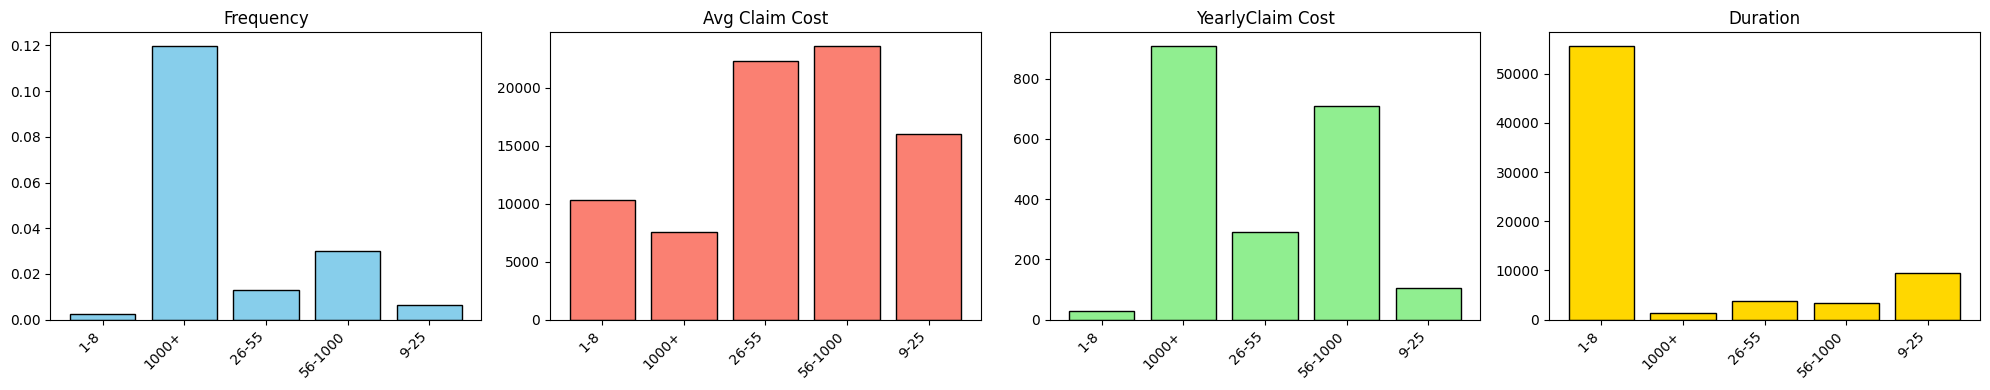

                    Duration  NumberOfClaims   ClaimCost  Frequency  AvgClaimCost  YearlyClaimCost
CompanyAge_Group                                                                                  
0-2                8763.8520              17   236752.00   0.001940  13926.588235        27.014605
19-35             17649.9434             125  2073500.05   0.007082  16588.000400       117.479133
3-7               18838.2174              64  1158980.16   0.003397  18109.065000        61.522815
36-50              4070.7878              39   323031.40   0.009580   8282.856410        79.353534
51+                2932.0188             142  1046199.33   0.048431   7367.600915       356.818766
8-18              21253.0584             122  2276030.38   0.005740  18655.986721       107.091899
Claims Check: OK
Stability Check: OK


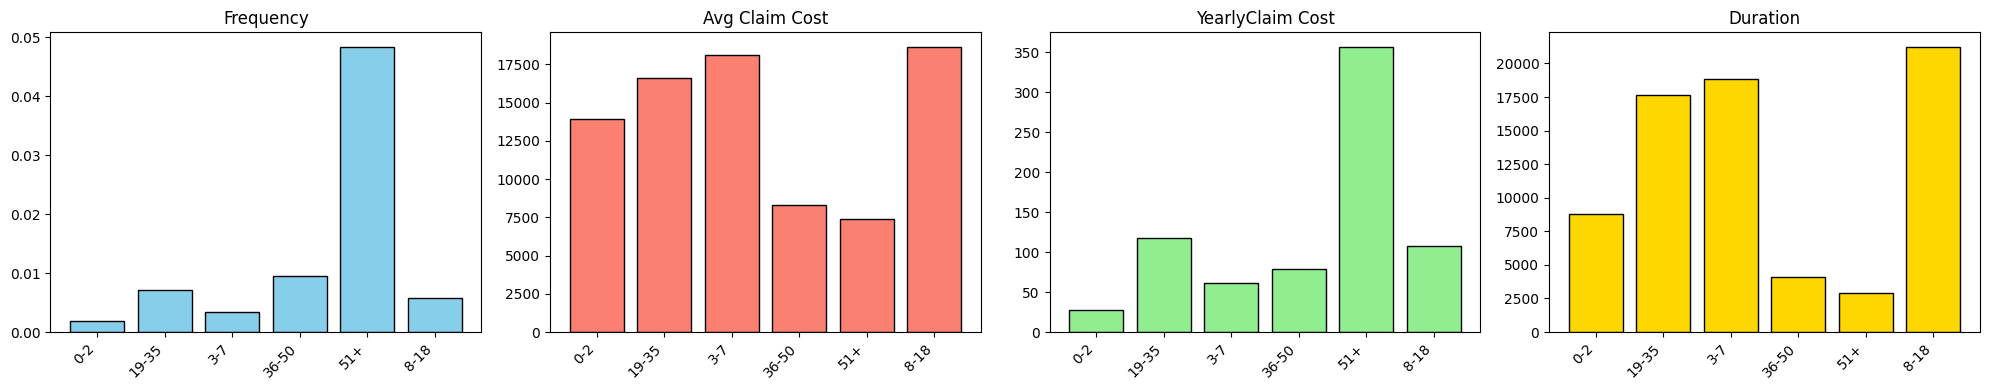

                         Duration  NumberOfClaims   ClaimCost  Frequency  AvgClaimCost  YearlyClaimCost
FinancialRating_Group                                                                                  
A/Standard             27968.0515             121  1364583.32   0.004326  11277.548099        48.790790
AA                     20616.3151             149  2259462.13   0.007227  15164.175369       109.595828
AAA                    11247.6134             203  2962098.06   0.018048  14591.616059       263.353474
B/C                     8546.9747              24   323840.81   0.002808  13493.367083        37.889525
New                     5128.9231              12   204509.00   0.002340  17042.416667        39.873673
Claims Check: OK
Stability Check: OK


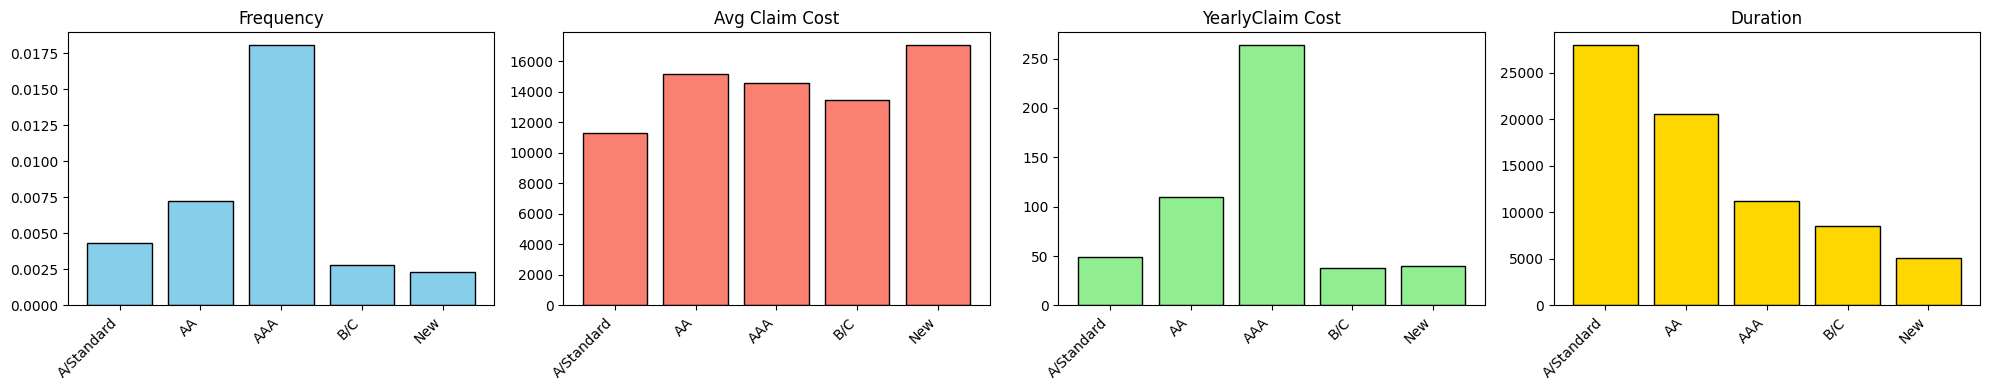

                        Duration  NumberOfClaims   ClaimCost  Frequency  AvgClaimCost  YearlyClaimCost
TravellingArea_Group                                                                                  
Nordics               13425.7751               9    83455.00   0.000670   9272.777778         6.216028
World                 60082.1027             500  7031038.32   0.008322  14062.076640       117.023839
Claims Check: OK
Stability Check: OK


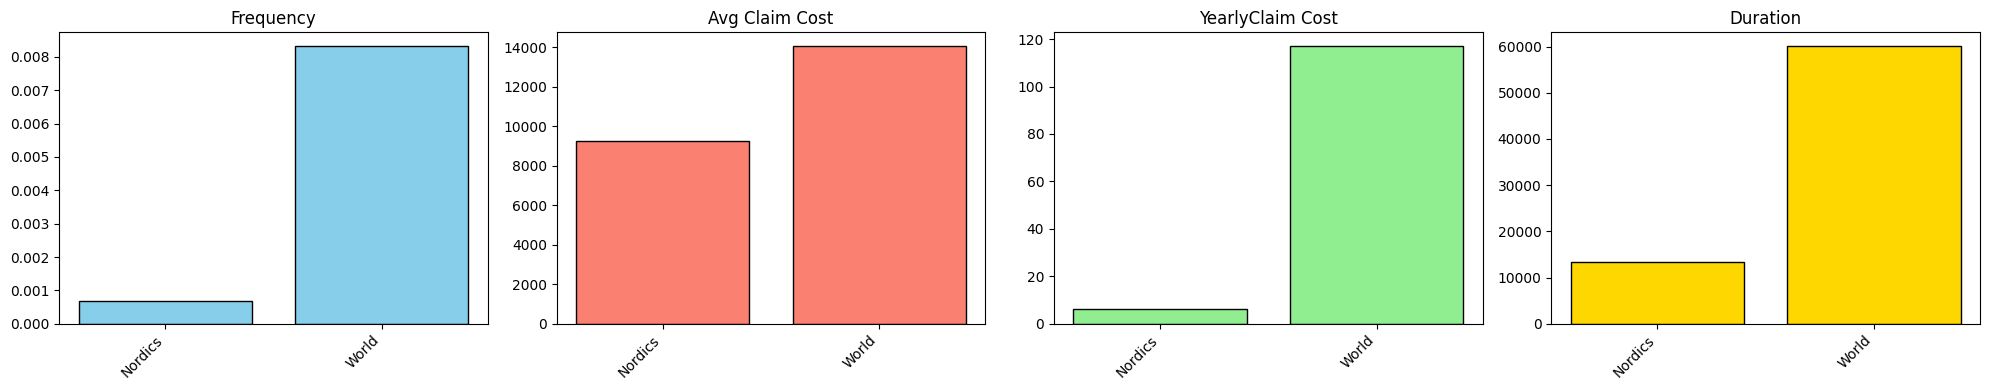

                  Duration  NumberOfClaims   ClaimCost  Frequency  AvgClaimCost  YearlyClaimCost
Activity_Group                                                                                  
Industry          474.8994               3    66538.00   0.006317  22179.333333       140.109674
Other           60766.9320             413  5654858.58   0.006796  13692.151525        93.058155
Service         12266.0464              93  1393096.74   0.007582  14979.534839       113.573412
Claims Check: OK
Stability Check: OK


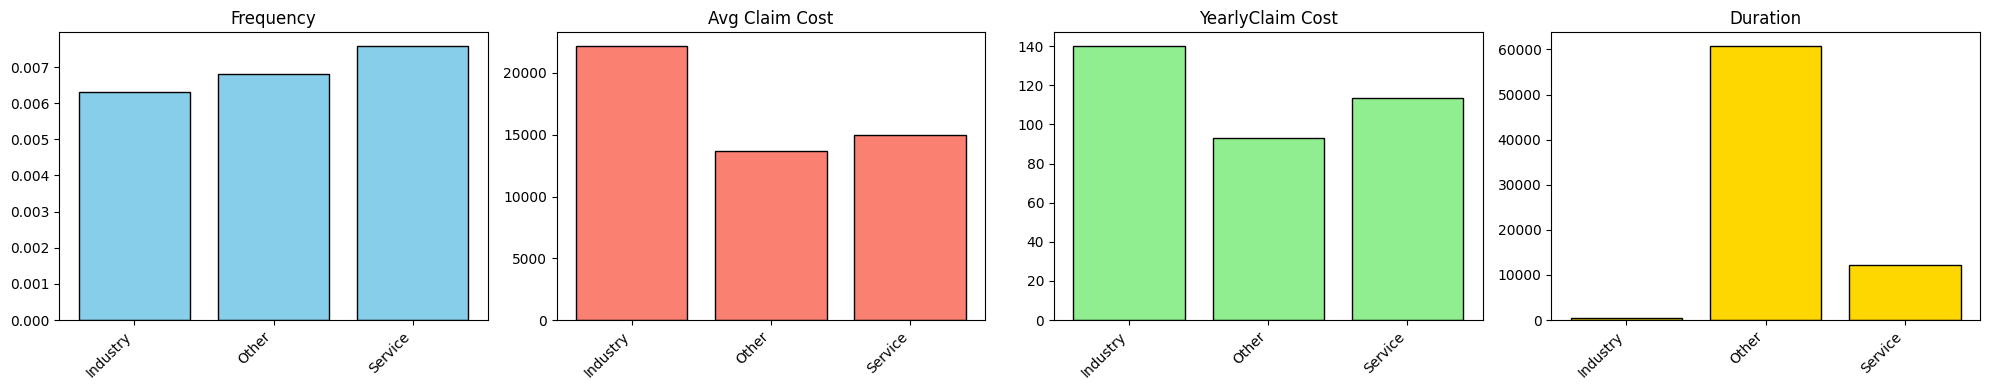

                  Duration  NumberOfClaims   ClaimCost  Frequency  AvgClaimCost  YearlyClaimCost
DangerousAreas                                                                                  
Excluded        73208.1882             481  6676710.44    0.00657  13880.894886        91.201689
Not Excluded      299.6896              28   437782.88    0.09343  15635.102857      1460.787695
Claims Check: OK
Stability Check: OK


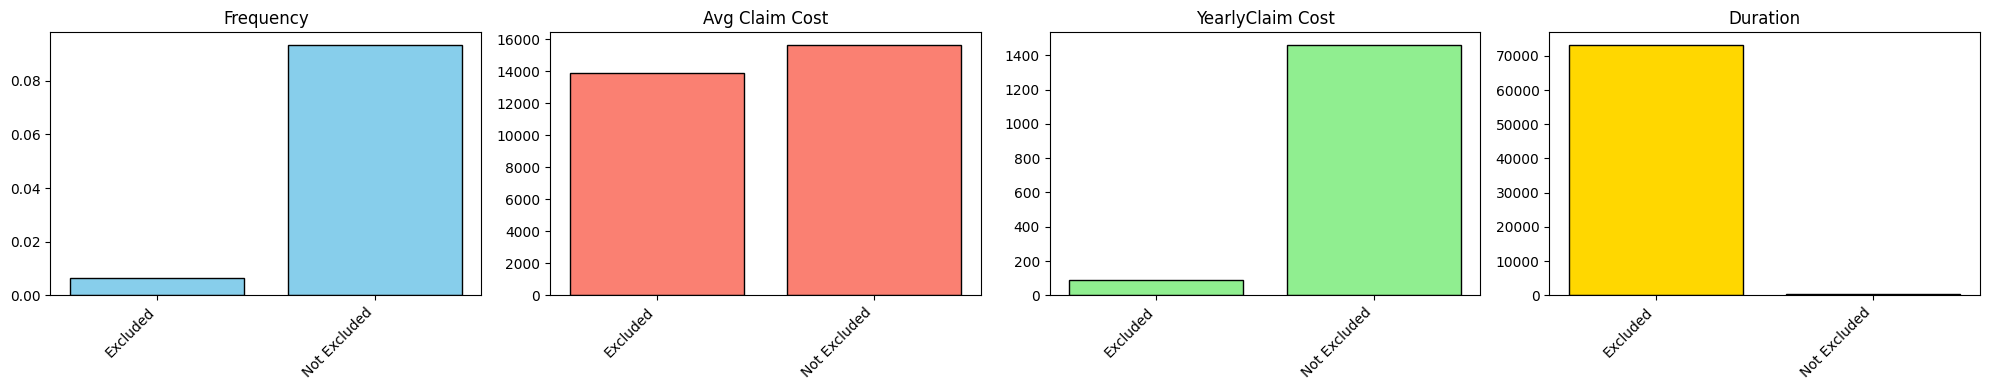

In [17]:
features_to_check = [
    'NumberOfPersons_Group', 'CompanyAge_Group', 
    'FinancialRating_Group', 'TravellingArea_Group', 'Activity_Group', 'DangerousAreas'
]

for feature in features_to_check:
    validate_and_plot_grouping(df, feature)

## GLM Analysis

In [18]:
# Define logical orders for all models (including Model 3 merged groups)
logical_orders = {
    'NumberOfPersons_Group': ['1-8', '9-25', '26-55', '56-1000', '1000+'],
    'CompanyAge_Group': ['0-2', '3-7', '0-7', '8-18', '19-35', '36-50', '51+'], 
    'FinancialRating_Group': ['AAA', 'AA', 'A/Standard', 'B/C', 'New', 'B/C/New'],
    'Activity_Group': ['Other', 'Industry', 'Service'],
    'TravellingArea_Group': ['Nordics', 'World'],
    'DangerousAreas': ['Excluded', 'Not Excluded']
}

In [19]:
def build_glm_pipeline(df_raw, features, model_num):
    """Perform GLM analysis, creating Frequency and Severity Model"""
    
    df_train_agg = df_raw.groupby(features, observed=False).agg(
        Duration=('Duration', 'sum'),
        NumberOfClaims=('NumberOfClaims', 'sum'),
        ClaimCost=('ClaimCost', 'sum')
    ).reset_index()
    
    df_train_agg = df_train_agg[df_train_agg['Duration'] > 0]

    df_sev = df_train_agg[df_train_agg["NumberOfClaims"] > 0].copy()
    df_sev["AvgClaimCost"] = df_sev["ClaimCost"] / df_sev["NumberOfClaims"]

    freq_bases = {f: df_train_agg.groupby(f, observed=False)['Duration'].sum().idxmax() for f in features}
    sev_bases = {f: df_sev.groupby(f, observed=False)['NumberOfClaims'].sum().idxmax() for f in features}

    freq_formula = 'NumberOfClaims ~ ' + ' + '.join([f'C({f}, Treatment(reference="{freq_bases[f]}"))' for f in features])
    sev_formula = 'AvgClaimCost ~ ' + ' + '.join([f'C({f}, Treatment(reference="{sev_bases[f]}"))' for f in features])

    freq_model = glm(formula=freq_formula, data=df_train_agg, family=sm.families.Poisson(), exposure=df_train_agg["Duration"], missing="raise").fit()
    sev_model = glm(formula=sev_formula, data=df_sev, family=sm.families.Gamma(link=sm.genmod.families.links.Log()), var_weights=df_sev["NumberOfClaims"], missing="raise").fit()

    return {"name": model_num, "features": features, "freq_model": freq_model, "sev_model": sev_model, "df_train_agg": df_train_agg, "df_sev": df_sev}

def get_model_coefficients(model, col_name, confidence_alpha=0.05):
    """Extracts coefficients and confidence intervals, formatted and logically sorted."""

    coefs = np.exp(model.params[model.params.index.str.contains(col_name)])
    conf_int = np.exp(model.conf_int(alpha=confidence_alpha).loc[model.params.index.str.contains(col_name)])
    
    ref = re.sub(r"[\)].*", "", re.sub(r".*?[\=]", "", coefs.index[-1], 1))[1:-1]

    # Clean the index names 
    clean_idx = coefs.index.str.replace(r'.*\[T\.(.*)\]', r'\1', regex=True)
    coefs.index = clean_idx
    conf_int.index = clean_idx

    # Append the reference group (value = 1.0)
    coefs = pd.concat([coefs, pd.Series([1.0], index=[ref])])
    lower = pd.concat([conf_int[0], pd.Series([1.0], index=[ref])])
    upper = pd.concat([conf_int[1], pd.Series([1.0], index=[ref])])
    
    # Apply Logical Sorting
    if col_name in logical_orders:
        # Reindex based on the predefined list, ignoring categories not present in the current model
        order = [x for x in logical_orders[col_name] if x in coefs.index]
        coefs = coefs.reindex(order)
        lower = lower.reindex(order)
        upper = upper.reindex(order)
    else:
        coefs = coefs.sort_index()
        lower = lower.sort_index()
        upper = upper.sort_index()
        
    return coefs, lower, upper


def combine_and_plot_factors(results_dict, df_train):
    """Merges factors into the dataset and plots them."""
    
    features = results_dict["features"]
    f_model, s_model = results_dict["freq_model"], results_dict["sev_model"]

    for var in features:
        # Extract coefs and bounds
        f_coefs, f_lower, f_upper = get_model_coefficients(f_model, var)
        s_coefs, s_lower, s_upper = get_model_coefficients(s_model, var)

        # Merge main factors to df_train for predictions
        c_freq = pd.DataFrame(f_coefs, columns=[f"{var}_freq"]).rename_axis(var).reset_index()
        c_sev = pd.DataFrame(s_coefs, columns=[f"{var}_sev"]).rename_axis(var).reset_index()

        df_train = df_train.merge(c_freq, on=var, how="left").merge(c_sev, on=var, how="left")
        df_train[f"{var}_factor"] = df_train[f"{var}_freq"] * df_train[f"{var}_sev"]

        plt.figure(figsize=(15, 4))
        
        # Frequency
        plt.subplot(1, 3, 1)
        plt.plot(f_coefs.index.astype(str), f_coefs, marker='o', color='blue', label='Risk')
        plt.plot(f_lower.index.astype(str), f_lower, "g:", label="Lower CI")
        plt.plot(f_upper.index.astype(str), f_upper, "g:", label="Upper CI")
        plt.axhline(1, color="black", linestyle="dotted")
        plt.title(f"Frequency ({var})")
        plt.xticks(rotation=45, ha='right')
        plt.legend()
        
        # Severity
        plt.subplot(1, 3, 2)
        plt.plot(s_coefs.index.astype(str), s_coefs, marker='o', color='red', label='Risk')
        plt.plot(s_lower.index.astype(str), s_lower, "g:", label="Lower CI")
        plt.plot(s_upper.index.astype(str), s_upper, "g:", label="Upper CI")
        plt.axhline(1, color="black", linestyle="dotted")
        plt.title(f"Severity ({var})")
        plt.xticks(rotation=45, ha='right')
        plt.legend()
        
        # Combined Factor
        plt.subplot(1, 3, 3)
        combined_factor = f_coefs * s_coefs
        plt.plot(combined_factor.index.astype(str), combined_factor, marker='o', color='purple')
        plt.axhline(1, color="black", linestyle="dotted")
        plt.title(f"Combined ({var})")
        plt.xticks(rotation=45, ha='right')
               
        plt.tight_layout()
        plt.show()

    return df_train

def apply_interpolation(df_target, df_train, features):
    """Perform interpolation for numerical variable group using Duration-weighted average"""
    
    d = df_target.copy()
    d["ModelPredictionFactor"] = 1.0
    
    for var in features:
        if var in ['NumberOfPersons_Group', 'CompanyAge_Group']:
            raw_col = var.replace('_Group', '')
            knots = df_train.groupby(var, observed=False).apply(
                lambda x: pd.Series({'x': np.average(x[raw_col], weights=x['Duration']) if x['Duration'].sum()>0 else np.nan, 'y': x[f"{var}_factor"].iloc[0]})
            ).dropna().sort_values('x')
            factor_vals = np.interp(d[raw_col], knots['x'], knots['y'])
            d["ModelPredictionFactor"] *= factor_vals
        else:
            mapping = df_train[[var, f"{var}_factor"]].drop_duplicates().set_index(var)[f"{var}_factor"]
            d["ModelPredictionFactor"] *= d[var].map(mapping).fillna(1.0).astype(float)
            
    return d

### Model 1

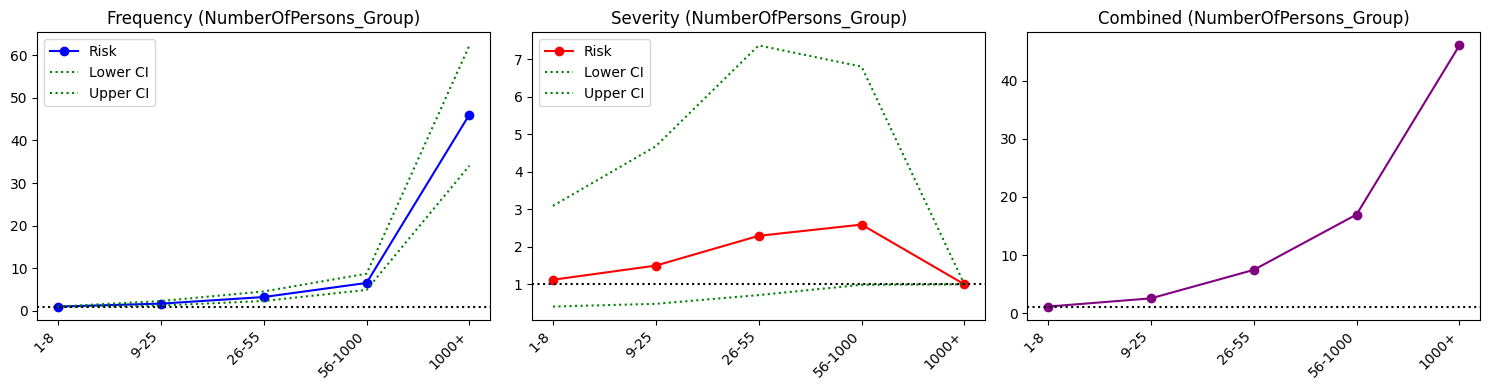

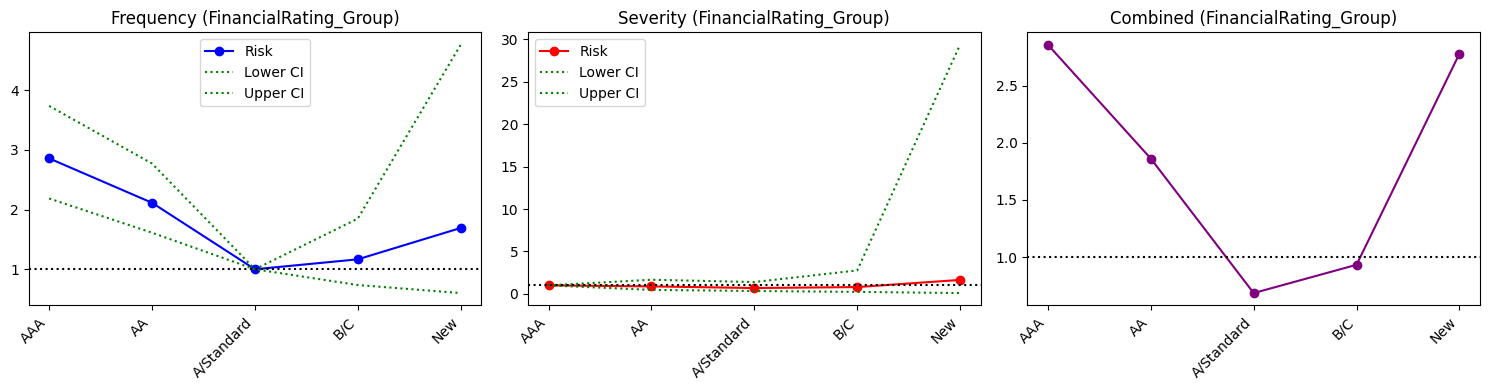

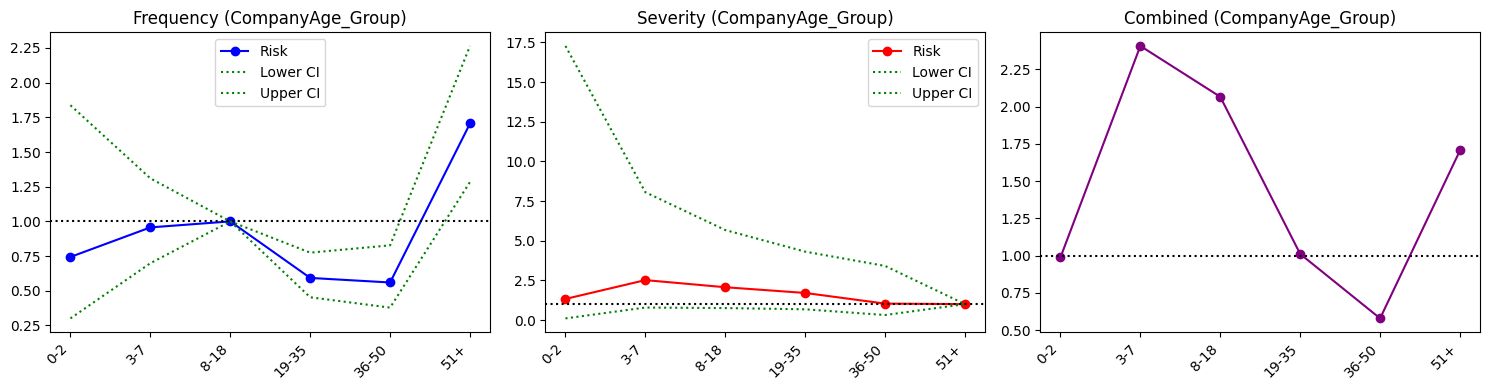

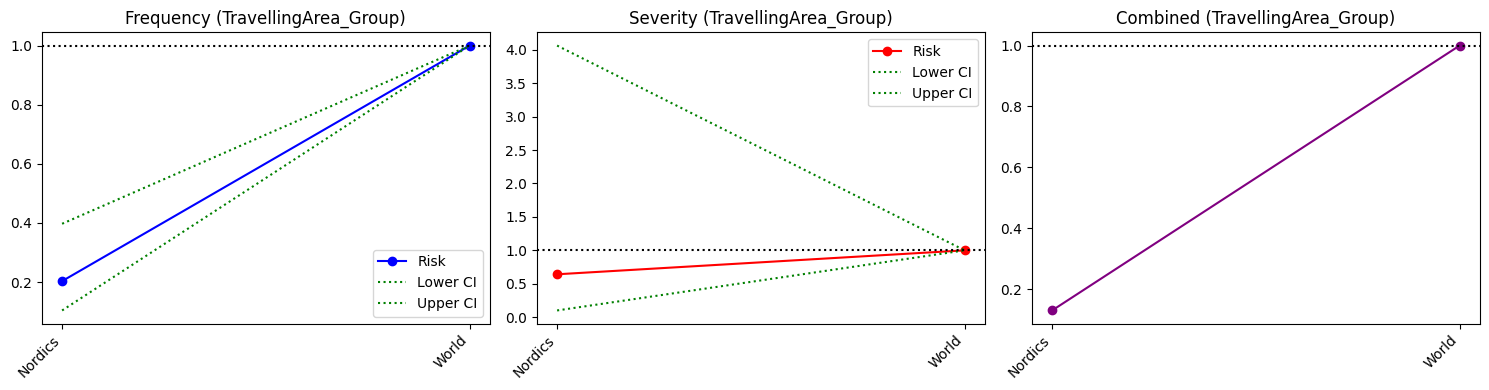

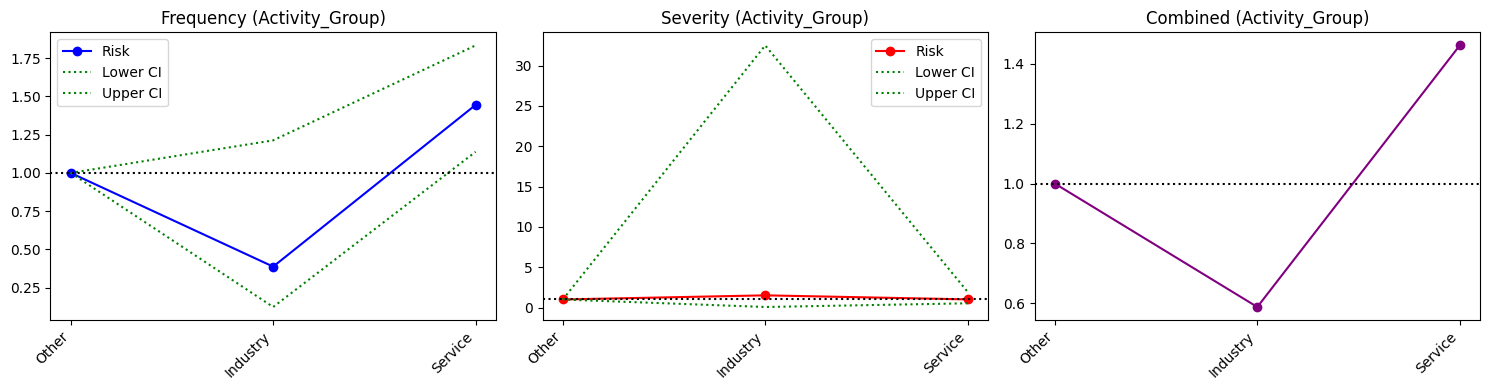

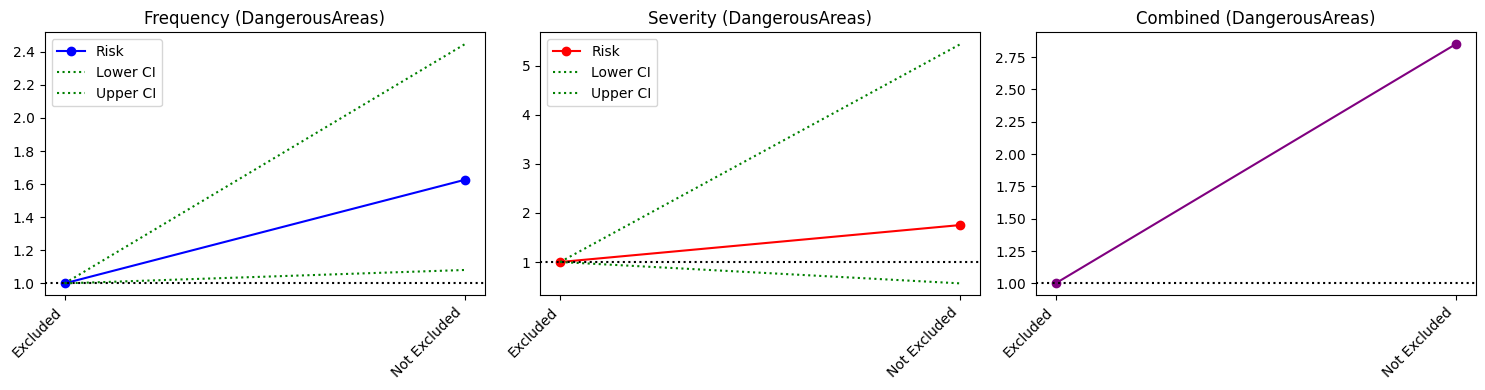

In [20]:
all_features = ['NumberOfPersons_Group', 'FinancialRating_Group', 'CompanyAge_Group', 'TravellingArea_Group', 'Activity_Group', 'DangerousAreas']

df_m1 = df.copy()

model_1_results = build_glm_pipeline(df_m1, all_features, "Model 1 (Full)")
df_m1 = combine_and_plot_factors(model_1_results, df_m1)
df_m1 = apply_interpolation(df_m1, df_m1, all_features)

### Model 2

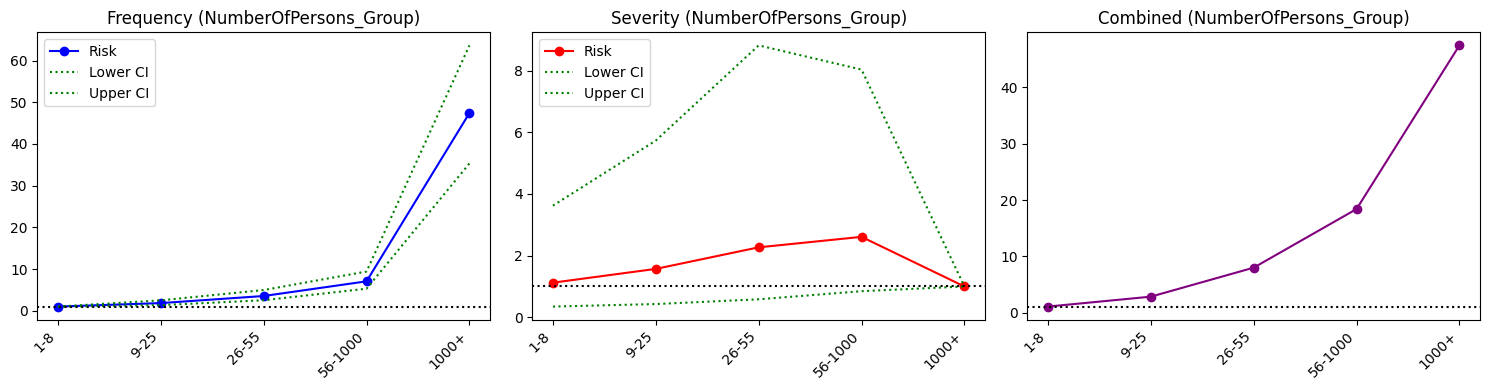

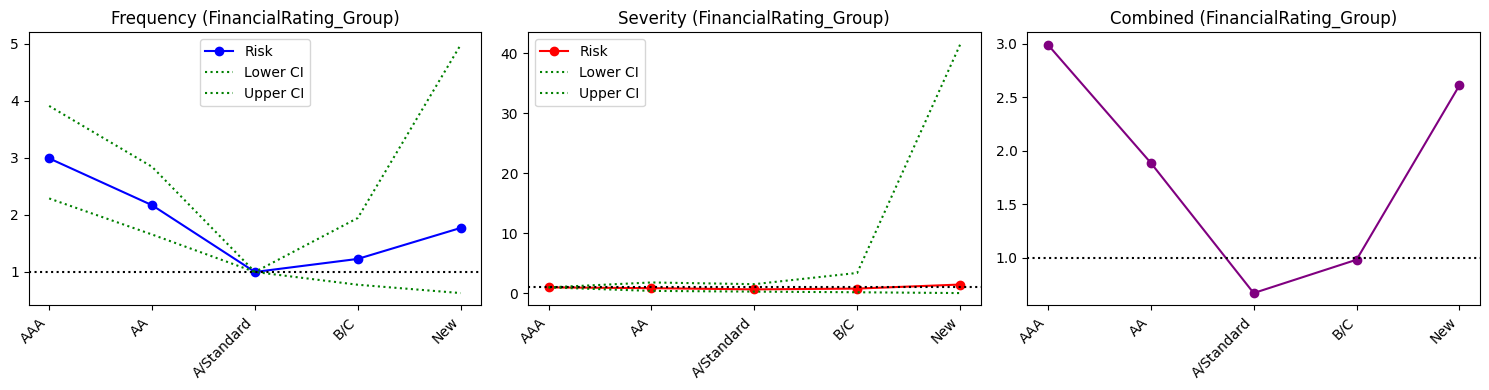

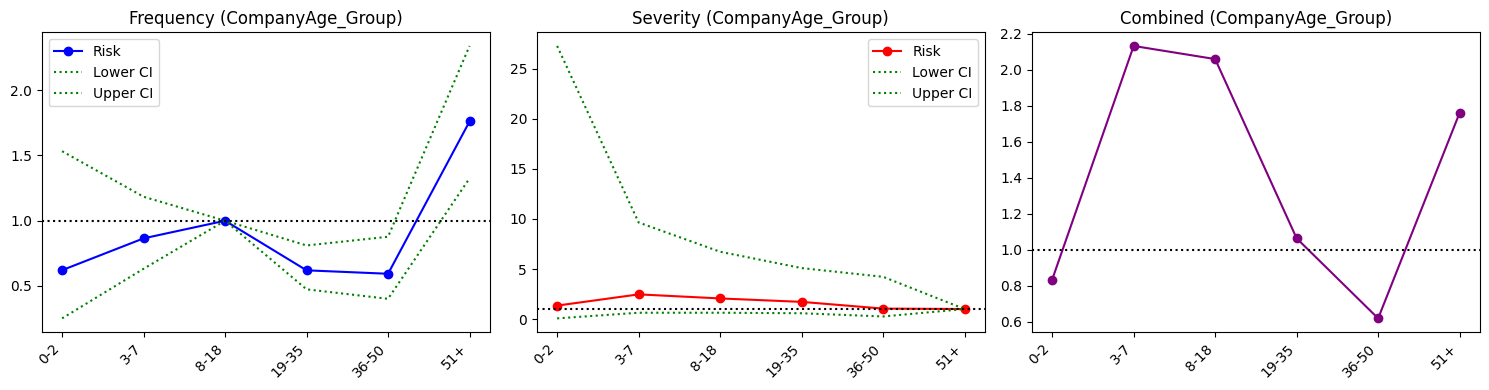

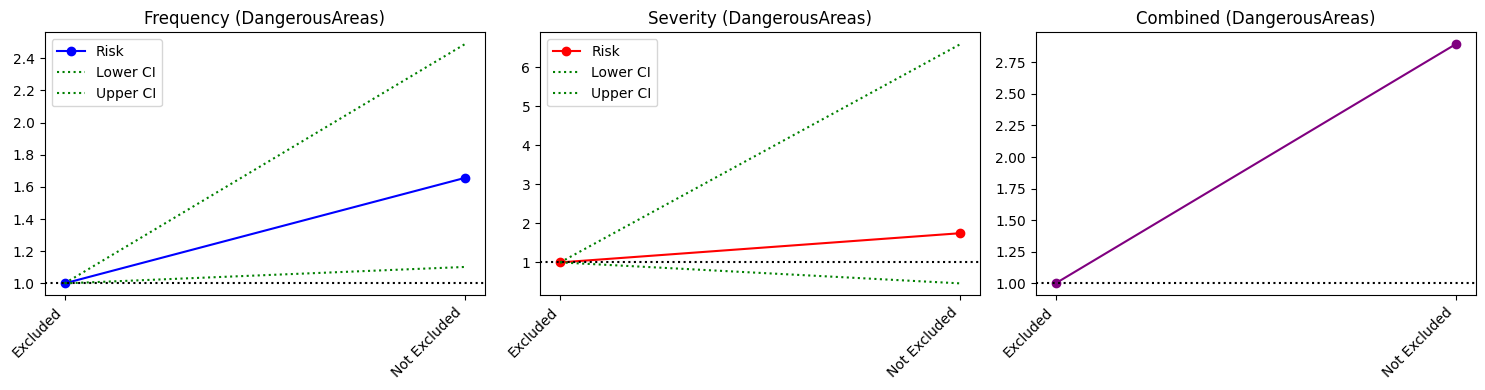

In [21]:
model_2_features = ['NumberOfPersons_Group', 'FinancialRating_Group', 'CompanyAge_Group', 'DangerousAreas']

df_m2 = df.copy()

Model_2_results = build_glm_pipeline(df_m2, model_2_features, "Model 2 (Reduced Features)")
df_m2 = combine_and_plot_factors(Model_2_results, df_m2)
df_m2 = apply_interpolation(df_m2, df_m2, model_2_features)

### Model 3

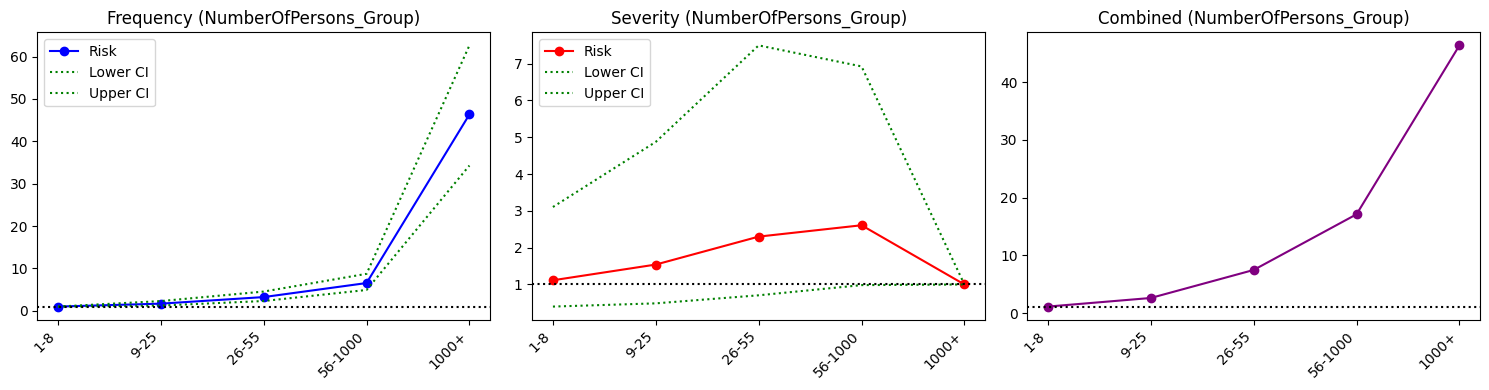

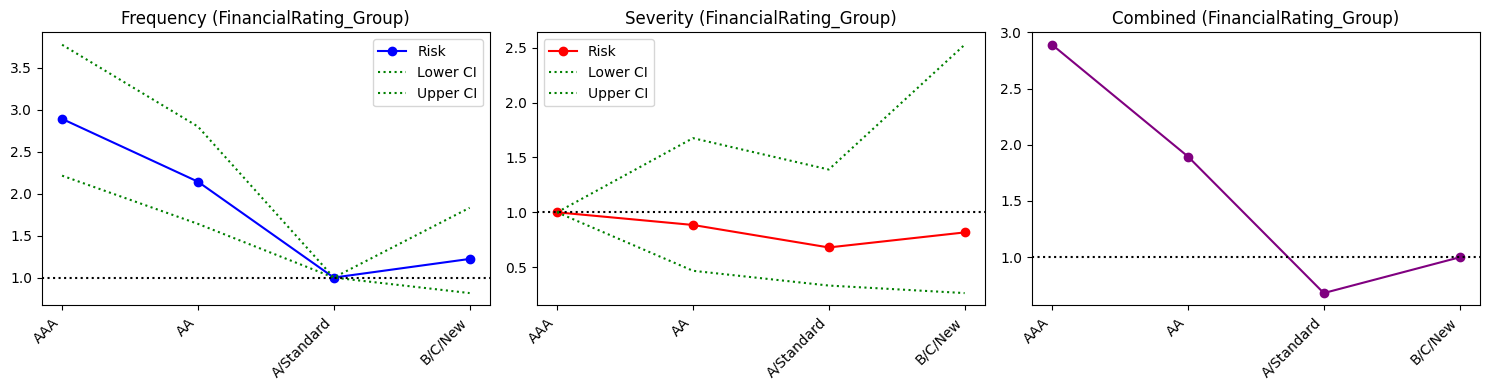

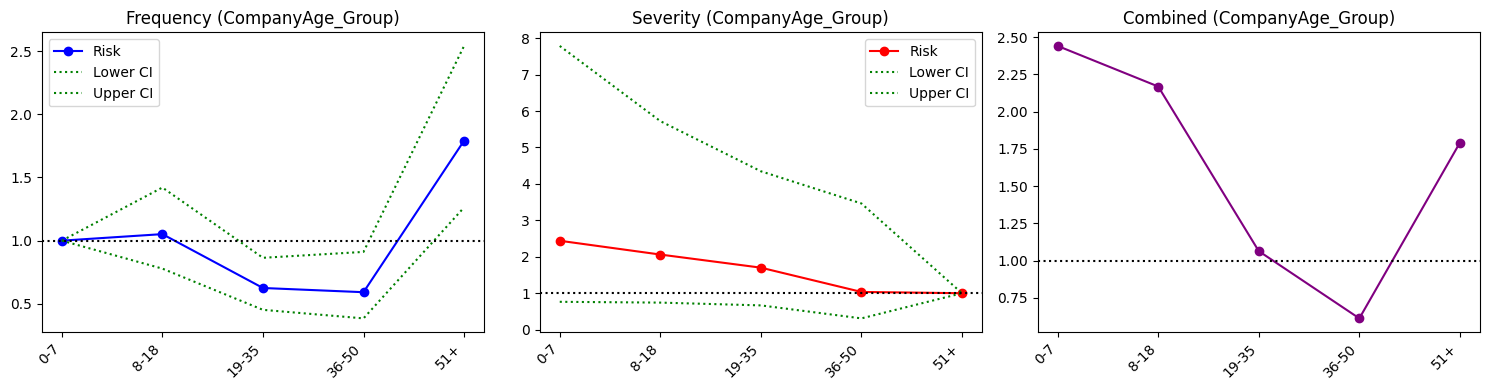

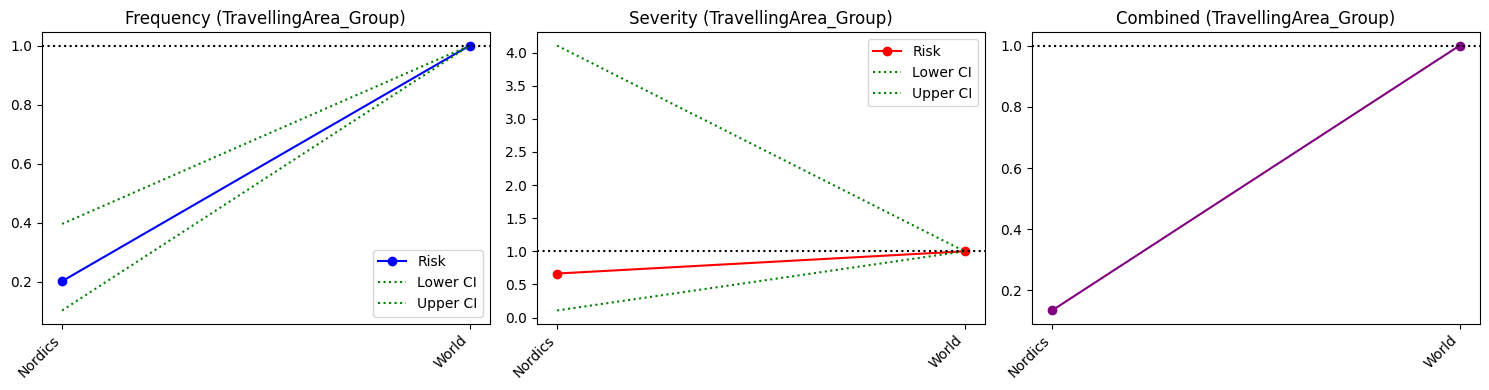

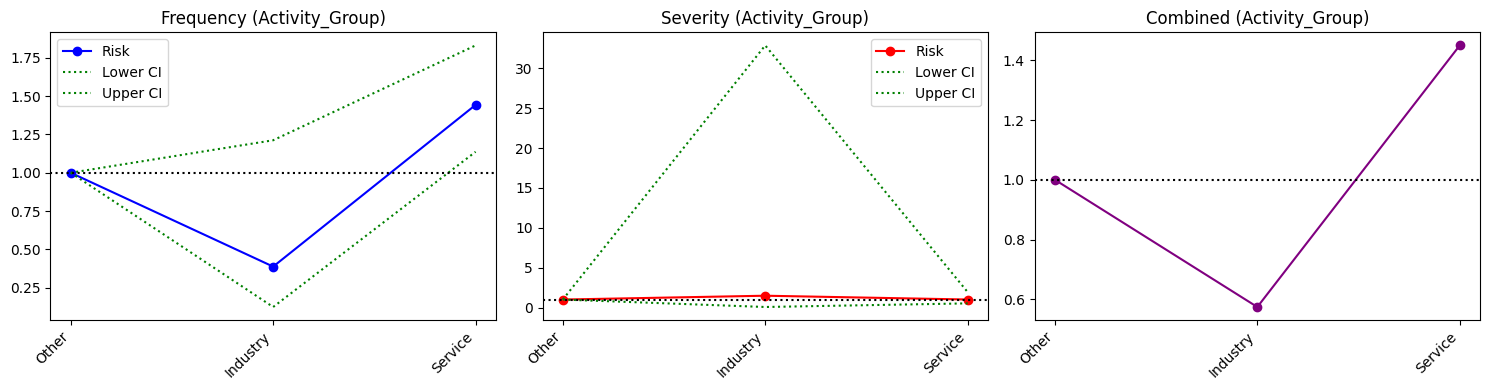

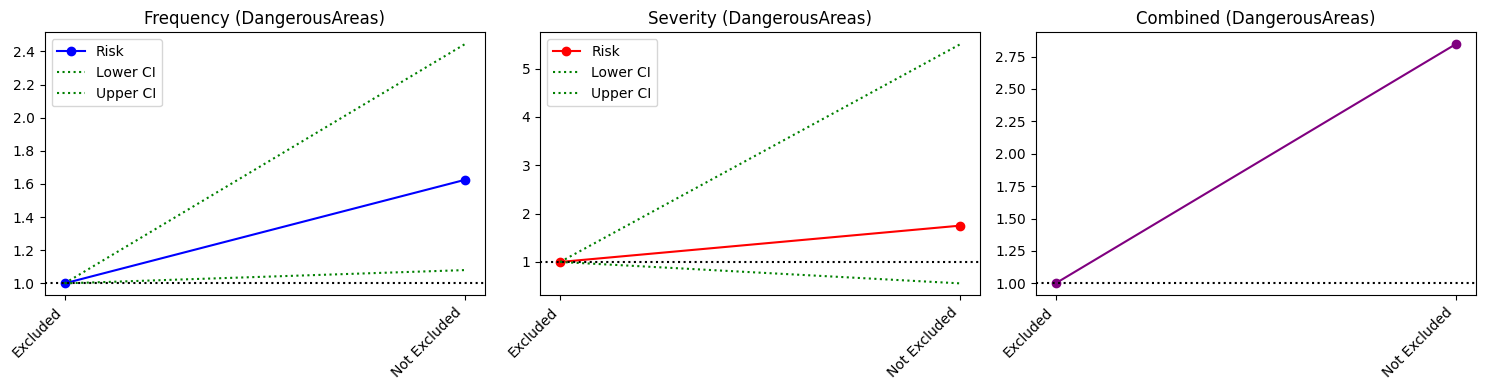

In [22]:
df_m3 = df.copy()

df_m3['FinancialRating_Group'] = df_m3['FinancialRating_Group'].astype(str).replace(['B/C', 'New'], 'B/C/New').astype('category')
df_m3['CompanyAge_Group'] = df_m3['CompanyAge_Group'].astype(str).replace(['0-2', '3-7'], '0-7').astype('category')

model_3_features = all_features # Uses same features as model 1, just updated grouping

Model_3_results = build_glm_pipeline(df_m3, model_3_features, "Model 3 (Merged Groups)")
df_m3 = combine_and_plot_factors(Model_3_results, df_m3)
df_m3 = apply_interpolation(df_m3, df_m3, model_3_features)

## Model Validation

### Modelling Test (Statistical Significance & Goodness of Fit)

##### Likelihood-Ratio (LR)

In [23]:
# Fit on standardized dataset to strictly compare Deviances
df_lrt = df.groupby(all_features, observed=False).agg(
    {"Duration": "sum", "NumberOfClaims": "sum", "ClaimCost": "sum"}
).reset_index().query("Duration > 0").copy()

# Create the Merged columns so they exist in both frequency and severity datasets
df_lrt['Fin_Merged'] = df_lrt['FinancialRating_Group'].astype(str).replace({'B/C': 'B/C/New', 'New': 'B/C/New'}).astype('category')
df_lrt['Age_Merged'] = df_lrt['CompanyAge_Group'].astype(str).replace({'0-2': '0-7', '3-7': '0-7'}).astype('category')

# Calculate Severity and split
df_lrt["AvgClaimCost"] = np.where(df_lrt["NumberOfClaims"] > 0, df_lrt["ClaimCost"] / df_lrt["NumberOfClaims"], 0)
df_lrt_sev = df_lrt.query("NumberOfClaims > 0").copy()

f_m1 = " ~ C(NumberOfPersons_Group) + C(FinancialRating_Group) + C(CompanyAge_Group) + C(TravellingArea_Group) + C(Activity_Group)"
f_m2 = " ~ C(NumberOfPersons_Group) + C(FinancialRating_Group) + C(CompanyAge_Group)"
f_m3 = " ~ C(NumberOfPersons_Group) + C(Fin_Merged) + C(Age_Merged) + C(TravellingArea_Group) + C(Activity_Group)"

def compare_lrt(f_full, f_red, comparison_name):
    print(f"\n{comparison_name}")
    
    # Loop through both Frequency and Severity configurations
    for target, data, fam, exp, weights, name in [
        ("NumberOfClaims", df_lrt, sm.families.Poisson(), df_lrt["Duration"], None, "Frequency"),
        ("AvgClaimCost", df_lrt_sev, sm.families.Gamma(link=sm.genmod.families.links.Log()), None, df_lrt_sev["NumberOfClaims"], "Severity")
    ]:
        m_full = glm(target + f_full, data=data, family=fam, exposure=exp, var_weights=weights).fit()
        m_red = glm(target + f_red, data=data, family=fam, exposure=exp, var_weights=weights).fit()
        
        df_diff = m_full.df_model - m_red.df_model
        lr_stat = max(0, (m_red.deviance - m_full.deviance) / m_full.scale)
        p_val = stats.chi2.sf(lr_stat, df_diff)
        
        result = "Reject Null (Keep Full)" if p_val < 0.05 else "Fail to Reject (Reduced is fine)"
        print(f"{name:<10} | LR Stat: {lr_stat:>6.2f} | DF Diff: {df_diff:>2.0f} | P-Value: {p_val:>10.4e} -> {result}")

compare_lrt(f_m1, f_m2, "Model 1 vs Model 2 (Dropping Features)")
compare_lrt(f_m1, f_m3, "Model 1 vs Model 3 (Merging Categories)")


Model 1 vs Model 2 (Dropping Features)
Frequency  | LR Stat:  51.21 | DF Diff:  3 | P-Value: 4.4097e-11 -> Reject Null (Keep Full)
Severity   | LR Stat:   0.22 | DF Diff:  3 | P-Value: 9.7362e-01 -> Fail to Reject (Reduced is fine)

Model 1 vs Model 3 (Merging Categories)
Frequency  | LR Stat:   0.46 | DF Diff:  2 | P-Value: 7.9526e-01 -> Fail to Reject (Reduced is fine)
Severity   | LR Stat:   0.19 | DF Diff:  2 | P-Value: 9.0787e-01 -> Fail to Reject (Reduced is fine)


##### AIC and BIC

In [24]:
def stepwise_selection(data, features, target, family, exposure=None, var_weights=None, criterion='AIC'):
    """Hybrid stepwise selection based on AIC or BIC."""
    
    included, excluded = [], list(features)
    
    def get_metric(feats):
        # Build formula. If no features, fit intercept only (1)
        formula = f"{target} ~ " + (" + ".join([f"C({f})" for f in feats]) if feats else "1")
        m = glm(formula, data=data, family=family, exposure=exposure, var_weights=var_weights).fit()
        return m.aic if criterion == 'AIC' else -2 * m.llf + np.log(m.nobs) * (m.df_model + 1)

    best_metric = get_metric([])
    print(f"Initial {criterion} (Null Model): {best_metric:.2f}")
    
    while True:
        changed = False
        
        # FORWARD STEP
        if excluded:
            forward_metrics = [(get_metric(included + [f]), f) for f in excluded]
            best_f_metric, best_f_feat = min(forward_metrics)
            if best_f_metric < best_metric:
                included.append(best_f_feat)
                excluded.remove(best_f_feat)
                best_metric = best_f_metric
                changed = True
                print(f" [+] Added {best_f_feat:<25} | {criterion}: {best_metric:.2f}")
        
        # BACKWARD STEP
        if included:
            backward_metrics = [(get_metric([f for f in included if f != drop_f]), drop_f) for drop_f in included]
            best_b_metric, best_b_feat = min(backward_metrics)
            if best_b_metric < best_metric:
                included.remove(best_b_feat)
                excluded.append(best_b_feat)
                best_metric = best_b_metric
                changed = True
                print(f" [-] Removed {best_b_feat:<25} | {criterion}: {best_metric:.2f}")
        
        if not changed:
            break
            
    print(f"Final {criterion} Features: {included}\n")
    return included

In [25]:
# Calculate AIC BIC for Frequency and Severity
configs = [
    ("FREQUENCY", "NumberOfClaims", df_lrt, sm.families.Poisson(), df_lrt["Duration"], None),
    ("SEVERITY", "AvgClaimCost", df_lrt_sev, sm.families.Gamma(link=sm.genmod.families.links.Log()), None, df_lrt_sev["NumberOfClaims"])
]

for model_name, target, data, fam, exp, weights in configs:
    for crit in ['AIC', 'BIC']:
        print(f"{model_name} MODEL: {crit}")
        stepwise_selection(data, all_features, target, fam, exposure=exp, var_weights=weights, criterion=crit)

FREQUENCY MODEL: AIC
Initial AIC (Null Model): 2112.69
 [+] Added NumberOfPersons_Group     | AIC: 1201.26
 [+] Added FinancialRating_Group     | AIC: 1031.58
 [+] Added CompanyAge_Group          | AIC: 973.42
 [+] Added TravellingArea_Group      | AIC: 937.24
 [+] Added Activity_Group            | AIC: 928.21
 [+] Added DangerousAreas            | AIC: 925.33
Final AIC Features: ['NumberOfPersons_Group', 'FinancialRating_Group', 'CompanyAge_Group', 'TravellingArea_Group', 'Activity_Group', 'DangerousAreas']

FREQUENCY MODEL: BIC
Initial BIC (Null Model): 2116.85
 [+] Added NumberOfPersons_Group     | BIC: 1222.07
 [+] Added FinancialRating_Group     | BIC: 1069.03
 [+] Added CompanyAge_Group          | BIC: 1031.67
 [+] Added TravellingArea_Group      | BIC: 999.65
 [+] Added Activity_Group            | BIC: 998.95
Final BIC Features: ['NumberOfPersons_Group', 'FinancialRating_Group', 'CompanyAge_Group', 'TravellingArea_Group', 'Activity_Group']

SEVERITY MODEL: AIC
Initial AIC (Null 

##### Wald Test

In [26]:
def perform_wald_test(model, model_name):
    """Extracts Wald Test statistics for individual levels."""
    
    print(f"Wald Test for {model_name}")
    print(f"{'Factor Level':<15} | {'Z-Statistic':<12} | {'P-Value':<12} | {'Significant?'}")
    print("-" * 60)
    
    # Extract metrics and drop the Intercept
    summary_df = pd.DataFrame({
        "Z_Statistic": model.tvalues,
        "P_Value": model.pvalues
    }).drop("Intercept", errors="ignore")
    
    # Replace the messy statsmodels prefix with just the category name
    summary_df.index = summary_df.index.str.replace(r'.*\[T\.(.*)\]', r'\1', regex=True)
    
    # significance check
    summary_df["Significant?"] = np.where(summary_df["P_Value"] < 0.05, "[YES]", "No")
    
    for index, row in summary_df.iterrows():
        print(f"{index:<15} | {row['Z_Statistic']:<12.4f} | {row['P_Value']:<12.4e} | {row['Significant?']}")
    print("\n")

In [27]:
perform_wald_test(model_1_results["freq_model"], "Frequency Model (Model 1)")
perform_wald_test(model_1_results["sev_model"], "Severity Model (Model 1)")

Wald Test for Frequency Model (Model 1)
Factor Level    | Z-Statistic  | P-Value      | Significant?
------------------------------------------------------------
1000+           | 24.8772      | 1.3123e-136  | [YES]
26-55           | 6.8111       | 9.6883e-12   | [YES]
56-1000         | 12.8216      | 1.2405e-37   | [YES]
9-25            | 3.3381       | 8.4366e-04   | [YES]
AA              | 5.4162       | 6.0874e-08   | [YES]
AAA             | 7.6734       | 1.6753e-14   | [YES]
B/C             | 0.6547       | 5.1263e-01   | No
New             | 0.9957       | 3.1938e-01   | No
0-2             | -0.6416      | 5.2114e-01   | No
19-35           | -3.8243      | 1.3115e-04   | [YES]
3-7             | -0.2752      | 7.8318e-01   | No
36-50           | -2.9095      | 3.6199e-03   | [YES]
51+             | 3.6924       | 2.2217e-04   | [YES]
Nordics         | -4.6588      | 3.1803e-06   | [YES]
Industry        | -1.6282      | 1.0348e-01   | No
Service         | 3.0225       | 2.5073e-03

### Business Test

#### Gini Score

In [28]:
def lorentz_curve(x, y, sort_by):
    assert x.shape == y.shape
    df_l2 = (
        pd.DataFrame(data={"x": x, "y": y, "sort_by": sort_by})
        .groupby(["sort_by"], as_index=False)
        .sum()
    )
    x_no_ties = df_l2["x"]
    y_no_ties = df_l2["y"]
    sort_by_no_ties = df_l2["sort_by"]
    sort = np.argsort(sort_by_no_ties)
    x_cumsum = pd.concat(
        [pd.Series([0]), x_no_ties.iloc[sort].cumsum() / x_no_ties.sum()]
    )
    y_cumsum = pd.concat(
        [pd.Series([0]), y_no_ties.iloc[sort].cumsum() / y_no_ties.sum()]
    )
    lorentz = np.trapezoid(x=x_cumsum, y=y_cumsum)
    diag = np.trapezoid(x=x_cumsum, y=x_cumsum)
    area_between_curves = diag - lorentz
    return area_between_curves, x_cumsum, y_cumsum


def GiniScore(df, x, y, sort_by):
    oracle_area, oracle_x, oracle_y = lorentz_curve(
        df[x], df[y], df[y] / df[x]
    )  # perfect order
    area, x_cumsum, y_cumsum = lorentz_curve(
        df[x], df[y], df[sort_by]
    )  # prediction order
    gini = area / oracle_area  # area relative perfect area
    return gini


def CreateGiniPlot(df, x, y, i="", figsize=(8, 6)):
    oracle_area, oracle_x, oracle_y = lorentz_curve(df[x], df[y], df[y] / df[x])

    fig = plt.figure(figsize=figsize)

    plt.plot(oracle_x, oracle_y, label=f"Sorted by {y}, perfect model")
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="black",
        label="Random baseline " + i + " (Gini {:.3f})".format(0),
    )

    plt.xlabel(
        "Fraction of total "
        + df[x].name
        + "\n"
        + "(ordered by model from safest to riskiest)"
    )
    plt.ylabel("Fraction of total " + df[y].name)

    def AddGiniModel(sort_by):

        area, x_cumsum, y_cumsum = lorentz_curve(df[x], df[y], df[sort_by])
        plt.plot(
            x_cumsum,
            y_cumsum,
            label=f"Sorted by {df[sort_by].name} (NormGini {area/oracle_area:.3f})",
        )

        handles, labels = plt.gca().get_legend_handles_labels()
        plt.legend(loc="upper left")

        gini = area / oracle_area
        return gini

    return AddGiniModel, fig

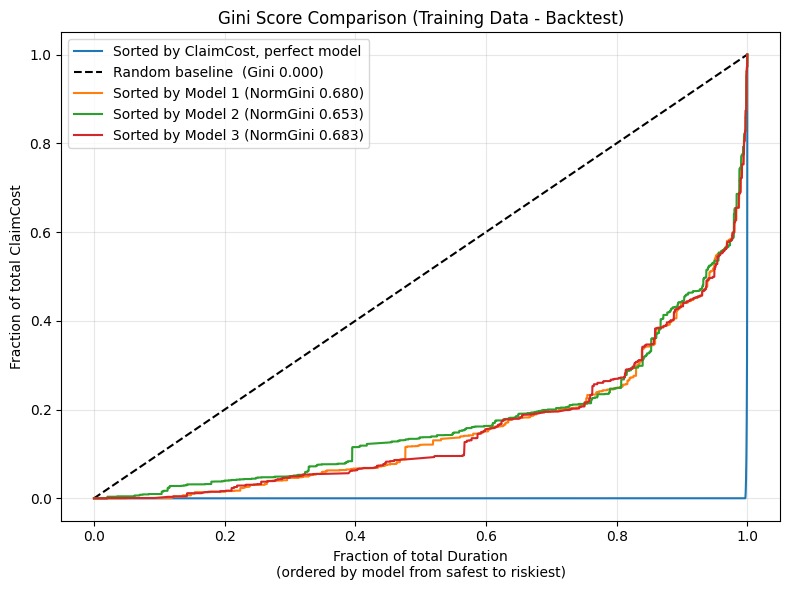


GINI SCORE COMPARISON (TRAINING DATA - BACKTEST) SCORES

Model 1 (Full Features):    0.6803
Model 2 (Reduced Features): 0.6528
Model 3 (Merged Groups):    0.6833



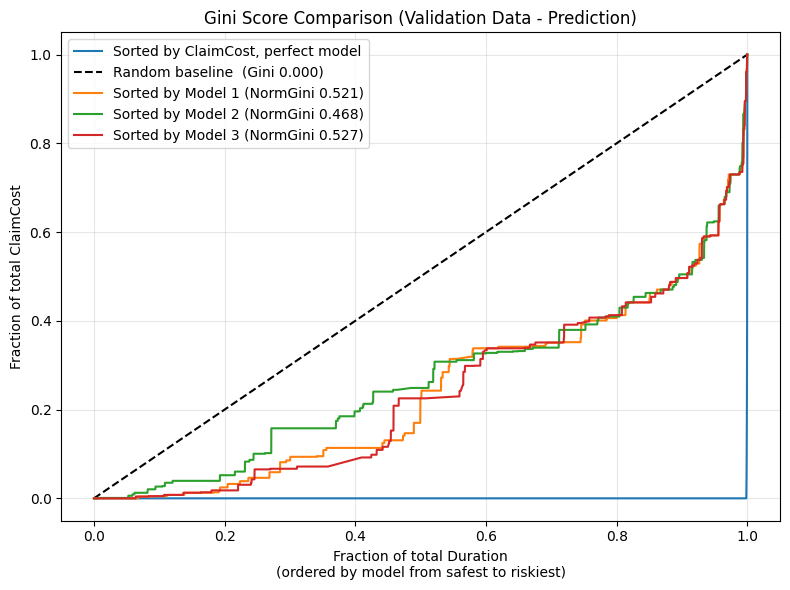


GINI SCORE COMPARISON (VALIDATION DATA - PREDICTION) SCORES

Model 1 (Full Features):    0.5209
Model 2 (Reduced Features): 0.4676
Model 3 (Merged Groups):    0.5274



In [29]:
# Prepare a validation dataset for Model 3 
df_valid_s3 = df_valid.copy()
df_valid_s3['FinancialRating_Group'] = df_valid_s3['FinancialRating_Group'].astype(str).replace({'B/C': 'B/C/New', 'New': 'B/C/New'}).astype('category')
df_valid_s3['CompanyAge_Group'] = df_valid_s3['CompanyAge_Group'].astype(str).replace({'0-2': '0-7', '3-7': '0-7'}).astype('category')

# Apply interpolation and store predictions directly as new columns
for dataset, s3_data in [(df, df), (df_valid, df_valid_s3)]:
    dataset['Model 1'] = apply_interpolation(dataset, df_m1, all_features)["ModelPredictionFactor"]
    dataset['Model 2'] = apply_interpolation(dataset, df_m2, model_2_features)["ModelPredictionFactor"]
    dataset['Model 3'] = apply_interpolation(s3_data, df_m3, model_3_features)["ModelPredictionFactor"]

def evaluate_and_plot_gini(data, title):
    """Generate the plot and print the formatted scores."""
    
    add_gini_model, fig = CreateGiniPlot(data, "Duration", "ClaimCost")
    
    # Calculate and plot the lines for each Model
    gini_s1 = add_gini_model("Model 1")
    gini_s2 = add_gini_model("Model 2")
    gini_s3 = add_gini_model("Model 3")
    
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print formatted output
    print(f"\n{title.upper()} SCORES\n")
    print(f"Model 1 (Full Features):    {gini_s1:.4f}")
    print(f"Model 2 (Reduced Features): {gini_s2:.4f}")
    print(f"Model 3 (Merged Groups):    {gini_s3:.4f}\n")

evaluate_and_plot_gini(df, "Gini Score Comparison (Training Data - Backtest)")
evaluate_and_plot_gini(df_valid, "Gini Score Comparison (Validation Data - Prediction)")

#### Risk Ratio (RR)

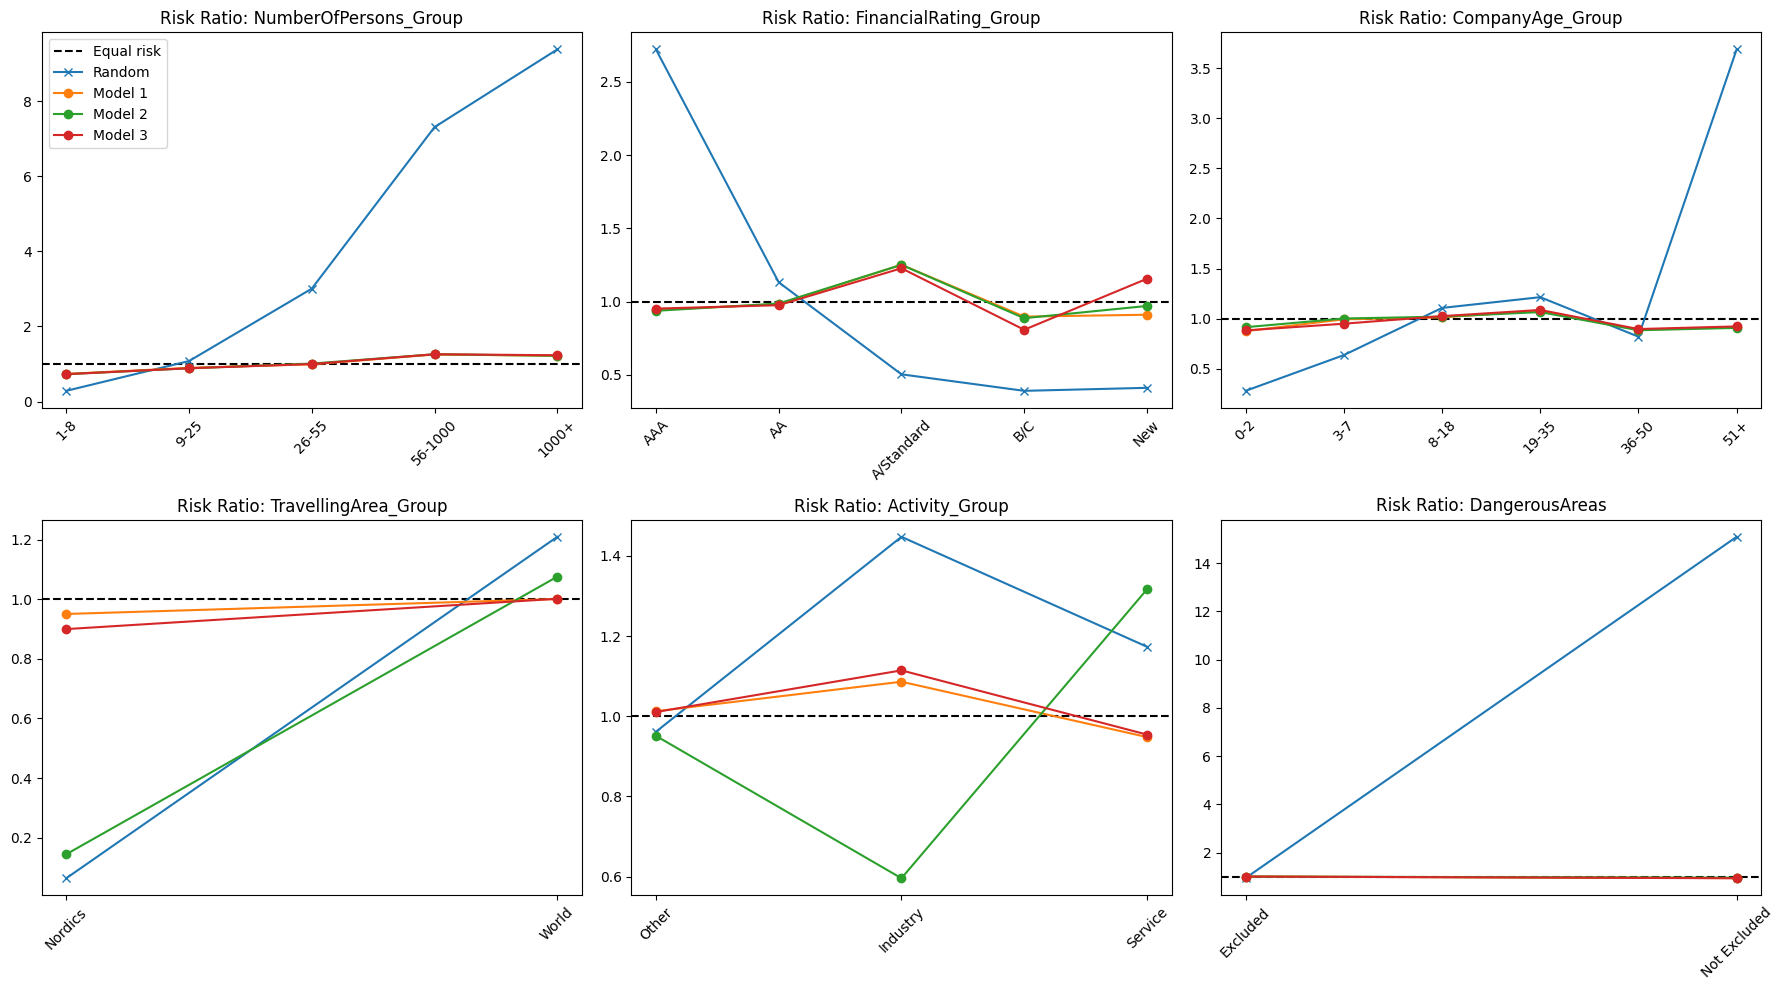

In [30]:
total_claim = df["ClaimCost"].sum()
df["random_pred"] = df["Duration"] * (total_claim / df["Duration"].sum())

df["S1_pred"] = df_m1["ModelPredictionFactor"] * df["Duration"] * (total_claim / (df_m1["ModelPredictionFactor"] * df["Duration"]).sum())
df["S2_pred"] = df_m2["ModelPredictionFactor"] * df["Duration"] * (total_claim / (df_m2["ModelPredictionFactor"] * df["Duration"]).sum())
df["S3_pred"] = df_m3["ModelPredictionFactor"] * df["Duration"] * (total_claim / (df_m3["ModelPredictionFactor"] * df["Duration"]).sum())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() 

for i, var in enumerate(all_features):
    df_rr = df.groupby(var, observed=False).agg({
        "ClaimCost": "sum", 
        "random_pred": "sum", 
        "S1_pred": "sum", 
        "S2_pred": "sum", 
        "S3_pred": "sum"
    }).dropna()

    if var in logical_orders:
        order = [x for x in logical_orders[var] if x in df_rr.index]
        df_rr = df_rr.reindex(order)

    ax = axes[i]

    # Target Line
    ax.axhline(1, color="k", linestyle="dashed", label="Equal risk")

    # Random Model
    ax.plot(df_rr.index.astype(str), df_rr["ClaimCost"] / df_rr["random_pred"], label="Random", marker='x')

    # GLM Models
    ax.plot(df_rr.index.astype(str), df_rr["ClaimCost"] / df_rr["S1_pred"], label="Model 1", marker='o')
    ax.plot(df_rr.index.astype(str), df_rr["ClaimCost"] / df_rr["S2_pred"], label="Model 2", marker='o')
    ax.plot(df_rr.index.astype(str), df_rr["ClaimCost"] / df_rr["S3_pred"], label="Model 3", marker='o')

    ax.set_title(f"Risk Ratio: {var}")
    ax.tick_params(axis='x', rotation=45)
    
    # Add legend only to the first plot to keep the grid clean
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()

## Leveling

In [31]:
total_claim_cost = df_m3["ClaimCost"].sum()
total_model_factor = (df_m3["ModelPredictionFactor"] * df_m3["Duration"]).sum()

base_level = total_claim_cost / total_model_factor
target_risk_ratio = 0.90
leveling_factor = base_level / target_risk_ratio

print(f"Base Level: {base_level:.4f}")
print(f"Target Risk Ratio: {target_risk_ratio:.4f}")
print(f"Leveling Factor: {leveling_factor:.4f}\n")

Base Level: 14.0123
Target Risk Ratio: 0.9000
Leveling Factor: 15.5692



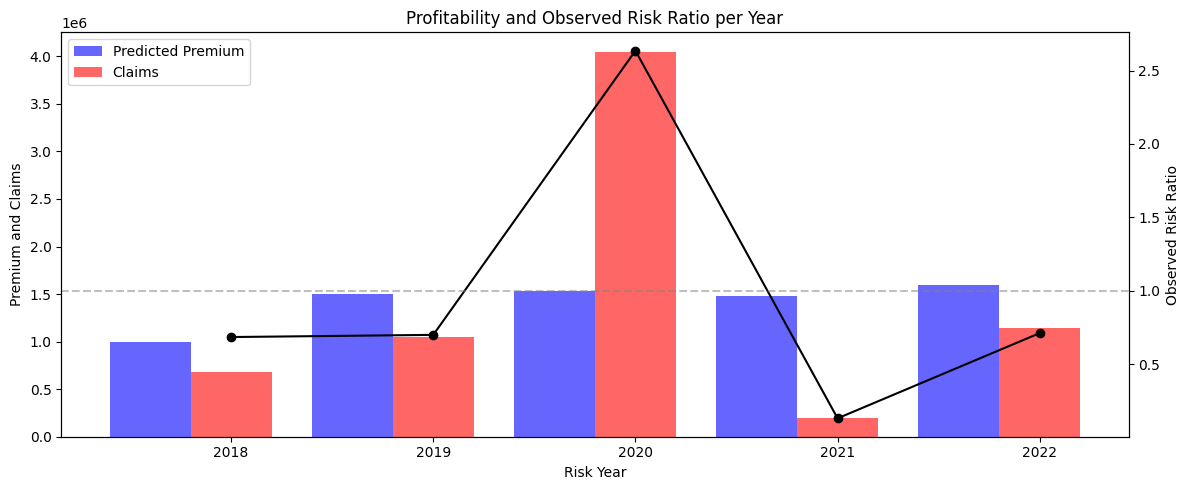

In [32]:
df_m3["predicted_claim_cost"] = df_m3["ModelPredictionFactor"] * df_m3["Duration"] * base_level

risk_progress = df_m3.groupby("RiskYear", observed=False).agg({
    "ClaimCost": "sum",
    "predicted_claim_cost": "sum"
})
risk_progress['risk_ratio'] = risk_progress['ClaimCost'] / risk_progress['predicted_claim_cost']

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(risk_progress.index - 0.4, risk_progress["predicted_claim_cost"], color="blue", alpha=0.6, width=0.4)
ax1.bar(risk_progress.index, risk_progress["ClaimCost"], color="red", alpha=0.6, width=0.4)
ax1.set_xlabel("Risk Year")
ax1.set_ylabel("Premium and Claims")
ax1.set_xticks(risk_progress.index) # Forces x-axis to only show whole years
ax1.legend(["Predicted Premium", "Claims"], loc="upper left")

# Creating a second y-axis to plot the observed risk ratio
ax2 = ax1.twinx()
ax2.plot(risk_progress.index, risk_progress["risk_ratio"], color="black", marker="o")
ax2.axhline(1.0, color="gray", linestyle="dashed", alpha=0.5) # Reference line for target
ax2.set_ylabel("Observed Risk Ratio")

plt.title("Profitability and Observed Risk Ratio per Year")
plt.tight_layout()
plt.show()

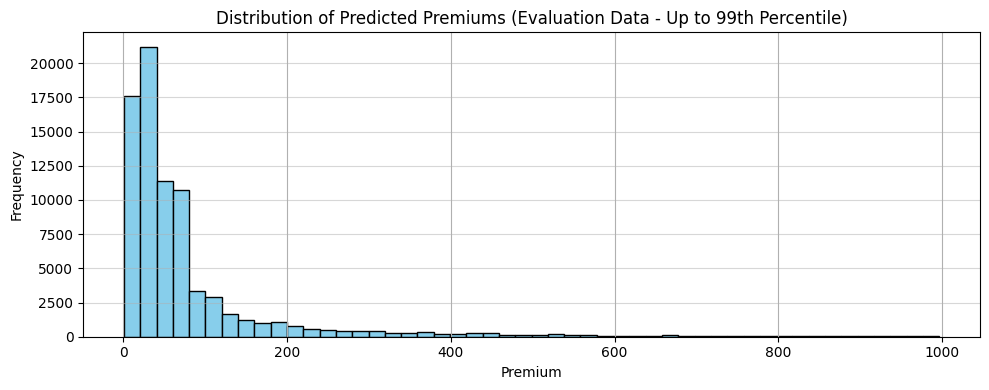

count    79631.000000
mean        98.291584
std        278.696102
min          0.801141
25%         24.050758
50%         41.696601
75%         79.846627
max      13653.481659
Name: premium, dtype: float64


In [33]:
# Apply Model 3 category merges to a fresh copy of the Evaluation data, just to be safe
df_eval_scen3 = df_eval.copy()
df_eval_scen3['FinancialRating_Group'] = df_eval_scen3['FinancialRating_Group'].astype(str).replace({'B/C': 'B/C/New', 'New': 'B/C/New'}).astype('category')
df_eval_scen3['CompanyAge_Group'] = df_eval_scen3['CompanyAge_Group'].astype(str).replace({'0-2': '0-7', '3-7': '0-7'}).astype('category')

# Apply the continuous model prediction factor
df_eval_scen3["ModelPredictionFactor"] = apply_interpolation(df_eval_scen3, df_m3, model_3_features)["ModelPredictionFactor"]

# Calculate premium
df_eval_scen3["premium"] = df_eval_scen3["ModelPredictionFactor"] * leveling_factor

plt.figure(figsize=(10, 4))

# Calculate the 99th percentile limit
p99_limit = df_eval_scen3["premium"].quantile(0.99)

# Filter the data just for the plot
plot_data = df_eval_scen3[df_eval_scen3["premium"] <= p99_limit]["premium"]

# Plot the filtered data
plot_data.hist(bins=50, color="skyblue", edgecolor="black")
plt.title(f"Distribution of Predicted Premiums (Evaluation Data - Up to 99th Percentile)")
plt.xlabel("Premium")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

print(df_eval_scen3["premium"].describe())

### Sanity Check

In [34]:
prems = df_eval_scen3["premium"]
missing, neg = prems.isna().sum(), (prems <= 0).sum()
p99, p_max = prems.quantile(0.99), prems.max()

print(f"Missing/NaN: {missing} | Negative/Zero: {neg}")
print(f"Max vs 99th: {p_max:.0f} vs {p99:.0f}")

train_claims = df["ClaimCost"].sum()
train_dur = df["Duration"].sum()

empirical_prem = train_claims / train_dur
eval_mean = prems.mean()

print(f"Historical Mean Premium (Training Data): {empirical_prem:.2f}")
print(f"Predicted Mean Premium (Eval Data): {eval_mean:.2f}")

cols = ['NumberOfPersons', 'CompanyAge', 'Activity_Group', 'FinancialRating_Group', 'TravellingArea_Group', 'DangerousAreas', 'premium']

display(pd.concat({
    'Top 3 Highest Risk': df_eval_scen3.nlargest(3, 'premium')[cols], 
    'Top 3 Lowest Risk': df_eval_scen3.nsmallest(3, 'premium')[cols]
}))

Missing/NaN: 0 | Negative/Zero: 0
Max vs 99th: 13653 vs 997
Historical Mean Premium (Training Data): 96.79
Predicted Mean Premium (Eval Data): 98.29


NumberOfPersons  CompanyAge Activity_Group  \
Top 3 Highest Risk 73714           5283.0    7.583847          Other   
                   74849           4747.0    7.583847          Other   
                   74382           5283.0    8.583162          Other   
Top 3 Lowest Risk  53773              2.0   47.504448       Industry   
                   59166              2.0   47.504448       Industry   
                   56377              2.0   48.503765       Industry   

                         FinancialRating_Group TravellingArea_Group  \
Top 3 Highest Risk 73714                   AAA                World   
                   74849                   AAA                World   
                   74382                   AAA                World   
Top 3 Lowest Risk  53773            A/Standard              Nordics   
                   59166            A/Standard              Nordics   
                   56377            A/Standard              Nordics   

                         DangerousAreas       premium  
Top 3 Highest Risk 73714   Not Excluded  13653.481659  
                   74849   Not Excluded  13653.481659  
                   74382   Not Excluded  13464.261606  
Top 3 Lowest Risk  53773       Excluded      0.801141  
                   59166       Excluded      0.801141  
                   56377       Excluded      0.844739